# CNN cod propriu

## Rezolvarea unor probleme de clasificare prin metode de învățare automată

Cerintele laboratorului:
- crearea unui set de date (imagini + etichetarea corespunzatoare)
- antrenarea unui model si testarea lui pentru clasificarea imaginilor normale vs sepia
     1. ANN (Artificial Neural Network) cu tool
     2. influenta (hyper)parametrilor
     3. ANN cod propriu
     4. CNN (Convolutional Neural Network) cod propriu

Steps:
1. Load data
2. Impartirea setului de date in train si test + verificarea echilibrului setului de date
3. Invatarea modelului
4. Testarea modelului + vizualizarea datelor
5. Metrici de performanta

In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
import numpy as np
from sklearn import neural_network
import matplotlib.pyplot as plt
from sklearn import neural_network
from sklearn import linear_model

### Step 1 + Step 2

In [2]:
from sklearn.model_selection import train_test_split
import numpy as np

df = pd.read_csv("metadata.csv")

# ia doar 20% din tot datasetul, stratificat
df_mic, _ = train_test_split(
    df,
    test_size=0.95 ,
    random_state=42,
    stratify=df['label']
)

# apoi sparge subsetul în train/test
train_df, test_df = train_test_split(
    df_mic,
    test_size=0.2,
    random_state=42,
    stratify=df_mic['label']
)

'''
train_df, test_df = train_test_split(
    df,
    # ia 20% din date pentru test
    test_size=0.20,
    # asemanator cu seed-ul de la random
    random_state=42,
    # pastreaza un echilibru intre labeluri (50% sepia, 50% noSepia)
    stratify=df['label']
)
'''

train_df.to_csv("train.csv", index=False)
test_df.to_csv("test.csv", index=False)

In [3]:
import os
from PIL import Image

# transforma imaginile in array-uri de numere
def load_images_from_df(df, folder):
    images = []
    for filename in df['filename']:
        path = os.path.join(folder, filename)
        # Deschidem, ne asigurăm că e RGB și transformăm în array de numere
        img = Image.open(path).convert('RGB')
        img_array = np.asarray(img)
        images.append(img_array)
    return np.array(images)


folder_date = 'processedImages64'

trainInputs = load_images_from_df(train_df, folder_date)
testInputs = load_images_from_df(test_df, folder_date)

trainOutputs = train_df['label'].map({'sepia': 1, 'noSepia': 0}).values
testOutputs = test_df['label'].map({'sepia': 1, 'noSepia': 0}).values

outputNames = ['noSepia','sepia']


def normalisation(trainData, testData):
    trainData = trainData.astype('float32') / 255.0
    testData = testData.astype('float32') / 255.0
    return trainData, testData

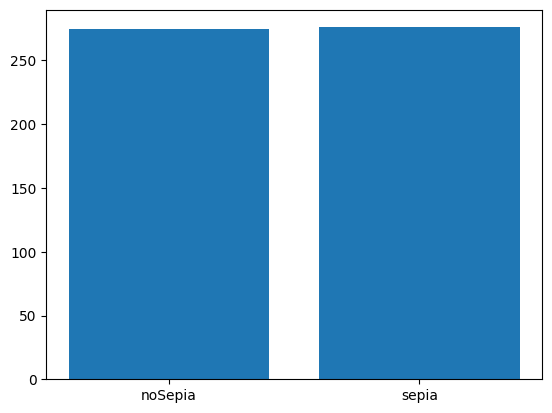

In [4]:
# check if the data is uniform distributed over classes
bins = range(3)
plt.hist(trainOutputs, bins, rwidth = 0.8)
bin_w = (max(bins) - min(bins)) / (len(bins) - 1)
plt.xticks(np.arange(min(bins)+bin_w/2, max(bins), bin_w), outputNames)
plt.show()

trainInputsNormalised, testInputsNormalised = normalisation(trainInputs, testInputs)

### Step 3 -> Invatarea modelului

In [5]:
from CNN import CNN
import random

classifier = CNN(iterations=30,learningRate=0.01,num_filters=2 ,layers=1,neurons=[16],filter_size = 3)

classifier.fit(trainInputsNormalised, trainOutputs)

Iteratia 1, Loss: 0.1172549040
Iteratia 2, Loss: 0.0956553891
Iteratia 3, Loss: 0.0888353625
Iteratia 4, Loss: 0.0736457248
Iteratia 5, Loss: 0.0651028414
Iteratia 6, Loss: 0.0564738226
Iteratia 7, Loss: 0.0501166314
Iteratia 8, Loss: 0.0469410550
Iteratia 9, Loss: 0.0386750595
Iteratia 10, Loss: 0.0369940284
Iteratia 11, Loss: 0.0363380371
Iteratia 12, Loss: 0.0333835805
Iteratia 13, Loss: 0.0306861552
Iteratia 14, Loss: 0.0363184638
Iteratia 15, Loss: 0.0274416722
Iteratia 16, Loss: 0.0261136861
Iteratia 17, Loss: 0.0233079583
Iteratia 18, Loss: 0.0226613097
Iteratia 19, Loss: 0.0231246033
Iteratia 20, Loss: 0.0200464229
Iteratia 21, Loss: 0.0205699267
Iteratia 22, Loss: 0.0223583243
Iteratia 23, Loss: 0.0191917313
Iteratia 24, Loss: 0.0186174643
Iteratia 25, Loss: 0.0168770680
Iteratia 26, Loss: 0.0132642191
Iteratia 27, Loss: 0.0164661780
Iteratia 28, Loss: 0.0130789021
Iteratia 29, Loss: 0.0119642142
Iteratia 30, Loss: 0.0140751314


### Step 4 -> Testarea modelului

In [6]:
predictedProb = classifier.predict(testInputsNormalised)
predictedLabels = [1 if p >= 0.5 else 0 for p in predictedProb]

### Step 5 -> Metrica de performanta

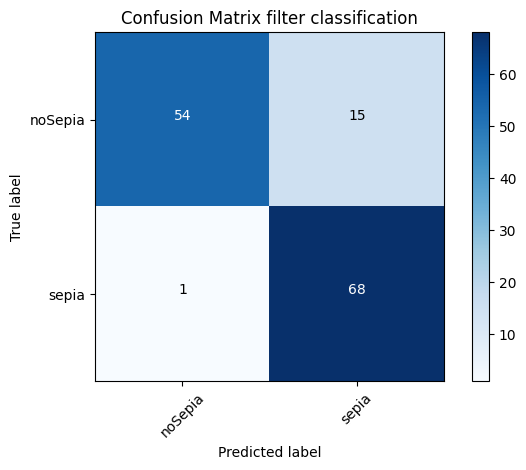

acc:  0.8840579710144928

precision: 
for sepia:  0.8192771084337349
for noSepia:  0.9818181818181818

recall: 
for sepia:  0.9855072463768116
for noSepia:  0.782608695652174


In [7]:
def plotConfusionMatrix(cm, classNames, title):
    from sklearn.metrics import confusion_matrix
    import itertools

    classes = classNames
    plt.figure()
    plt.imshow(cm, interpolation = 'nearest', cmap = 'Blues')
    plt.title('Confusion Matrix ' + title)
    plt.colorbar()
    tick_marks = np.arange(len(classNames))
    plt.xticks(tick_marks, classNames, rotation=45)
    plt.yticks(tick_marks, classNames)

    text_format = 'd'
    thresh = cm.max() / 2.
    for row, column in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(column, row, format(cm[row, column], text_format),
                horizontalalignment = 'center',
                color = 'white' if cm[row, column] > thresh else 'black')

    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()

    plt.show()

def evalMultiClass(realLabels, computedLabels, labelNames):
    from sklearn.metrics import confusion_matrix

    confMatrix = confusion_matrix(realLabels, computedLabels)
    acc = sum([confMatrix[i][i] for i in range(len(labelNames))]) / len(realLabels)
    precision = {}
    recall = {}
    for i in range(len(labelNames)):
        precision[labelNames[i]] = confMatrix[i][i] / sum([confMatrix[j][i] for j in range(len(labelNames))])
        recall[labelNames[i]] = confMatrix[i][i] / sum([confMatrix[i][j] for j in range(len(labelNames))])
    return acc, precision, recall, confMatrix


acc, prec, recall, cm = evalMultiClass(np.array(testOutputs), predictedLabels, outputNames)


plotConfusionMatrix(cm, outputNames, "filter classification")
print('acc: ', acc)

print('\nprecision: ')
print('for sepia: ',prec['sepia'])
print('for noSepia: ', prec['noSepia'])

print('\nrecall: ')
print('for sepia: ',recall['sepia'])
print('for noSepia: ', recall['noSepia'])